In [1]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
url = "http://stat.cmu.edu/~larry/health.txt"

resp = requests.get(url, verify=False)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text), sep=r"\s+", engine="python")
df.columns = df.columns.str.replace('"', '', regex=False).str.strip()
df.to_csv("health.csv", index=False)

print(df.head())
print(df.shape)

            y        age         tri        chol
"1"  0.344166  61.371018  255.998604  174.725537
"2"  0.468648  70.009314  303.203193  191.830690
"3"  0.011416  20.090352  469.998113  126.269968
"4"  0.472875  71.242094  146.105958  211.434928
"5"  0.000000  20.089902  221.786232  240.876589
(25, 4)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'stat.cmu.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [3]:
desc = df.describe()
print(desc)

               y        age         tri        chol
count  25.000000  25.000000   25.000000   25.000000
mean    0.246030  48.758531  276.303162  193.094222
std     0.236875  20.412605  116.442152   41.714612
min     0.000000  20.089902  121.814481  125.090296
25%     0.072238  32.297838  164.532195  171.406587
50%     0.157790  44.711648  266.090679  193.100387
75%     0.353329  61.371018  379.832963  227.054412
max     1.000000  99.000000  469.998113  248.683155


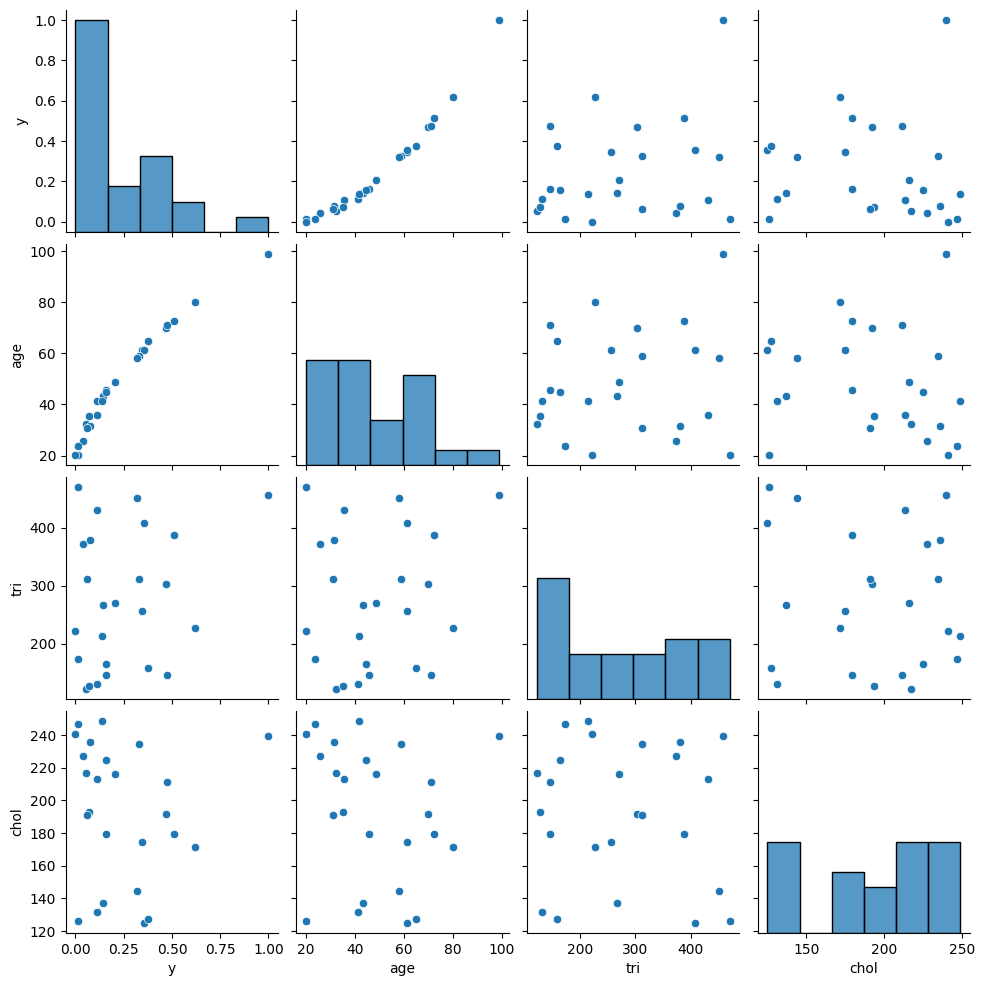

In [4]:
sns.pairplot(df)
plt.show()

$y$ seems to have some non linear dependence on age, and seems fairly uncorrelated with tri and chol

In [5]:
model = smf.ols("y ~ age + tri + chol", data=df).fit()

print(model.summary())
print(model.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     199.5
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.37e-15
Time:                        16:34:25   Log-Likelihood:                 43.350
No. Observations:                  25   AIC:                            -78.70
Df Residuals:                      21   BIC:                            -73.82
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4792      0.059     -8.121      0.0

Intercept   -0.479158
age          0.011237
tri          0.000254
chol         0.000555
dtype: float64
0.011237089871527014


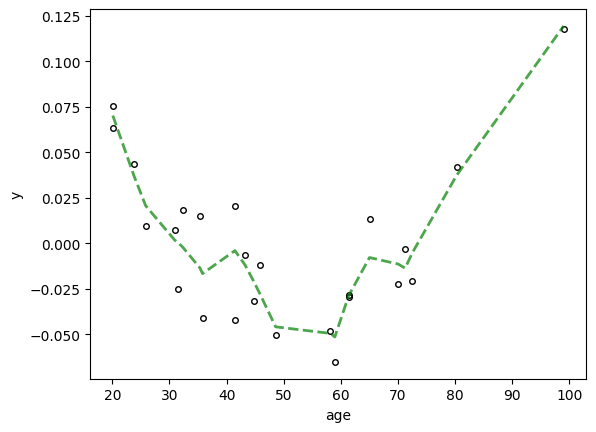

In [57]:
residuals = model.resid
fitted_vals = model.fittedvalues

smooth = lowess(residuals, df["age"], frac=0.3) 

plt.plot(df["age"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("age")
plt.ylabel("y")
plt.show()

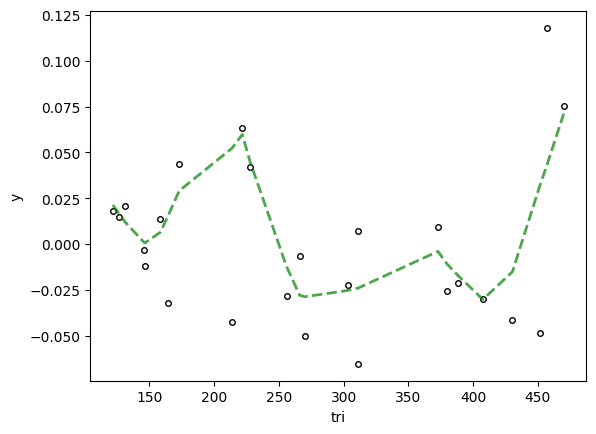

In [58]:
smooth = lowess(residuals, df["tri"], frac=0.3) 

plt.plot(df["tri"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("tri")
plt.ylabel("y")
plt.show()

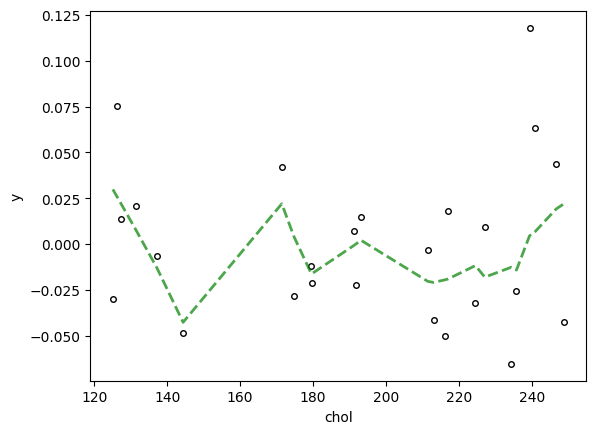

In [59]:
smooth = lowess(residuals, df["chol"], frac=0.3) 

plt.plot(df["chol"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("chol")
plt.ylabel("y")
plt.show()

### Plotting the studentised residuals

In [91]:
influence = model.get_influence()
jackknife_residuals = influence.resid_studentized_external

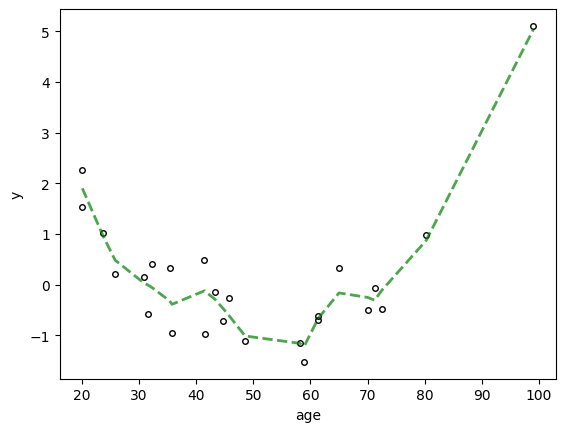

In [114]:
smooth = lowess(jackknife_residuals, df["age"], frac=0.3) 
# smooth2 = lowess(residuals, df["age"], frac=0.3) 

plt.plot(df["age"], jackknife_residuals, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df["age"], residuals, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("age")
plt.ylabel("y")
plt.show()

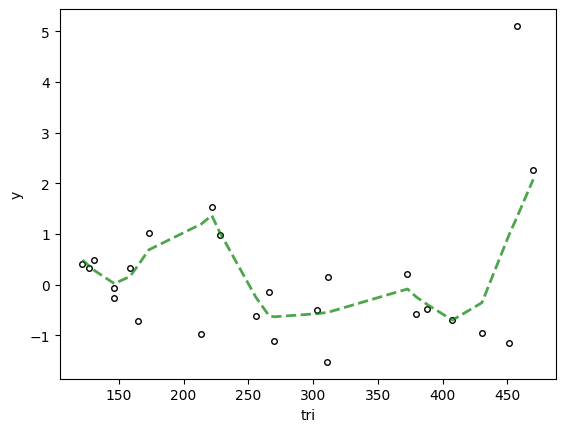

In [96]:
smooth = lowess(jackknife_residuals, df["tri"], frac=0.3) 
# smooth2 = lowess(residuals, df["tri"], frac=0.3) 

plt.plot(df["tri"], jackknife_residuals, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df["tri"], residuals, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("tri")
plt.ylabel("y")
plt.show()

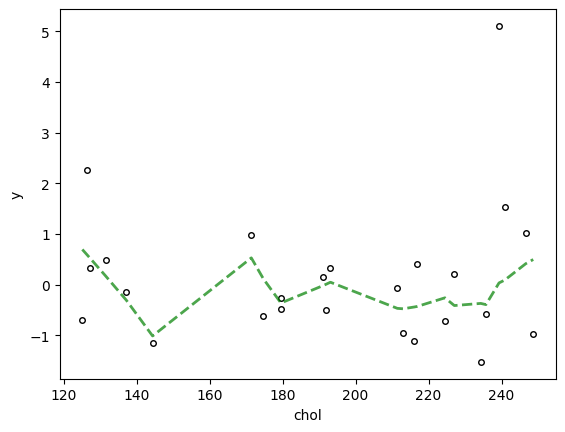

In [95]:
smooth = lowess(jackknife_residuals, df["chol"], frac=0.3) 
# smooth2 = lowess(residuals, df["chol"], frac=0.3) 

plt.plot(df["chol"], jackknife_residuals, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df["chol"], residuals, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("chol")
plt.ylabel("y")
plt.show()

### Plotting cooks distance

In [97]:
cookd, _ = influence.cooks_distance
indices = range(0, len(cookd))

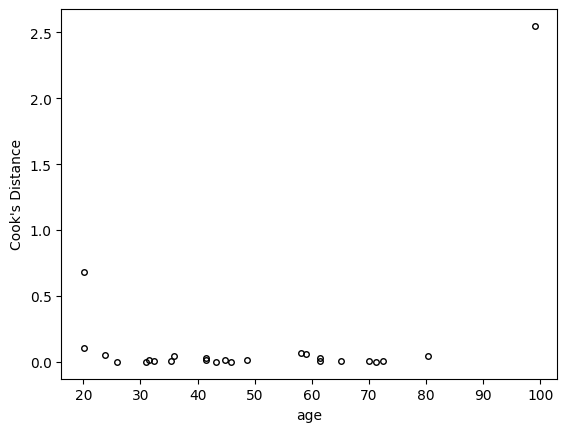

In [98]:
# smooth = lowess(cookd, df["age"], frac=0.3) 

plt.plot(df["age"], cookd, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("age")
plt.ylabel("Cook's Distance")
plt.show()

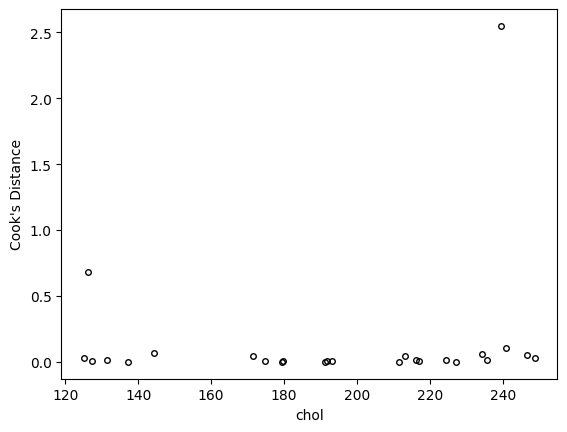

In [99]:
# smooth = lowess(cookd, df["chol"], frac=0.3) 

plt.plot(df["chol"], cookd, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("chol")
plt.ylabel("Cook's Distance")
plt.show()

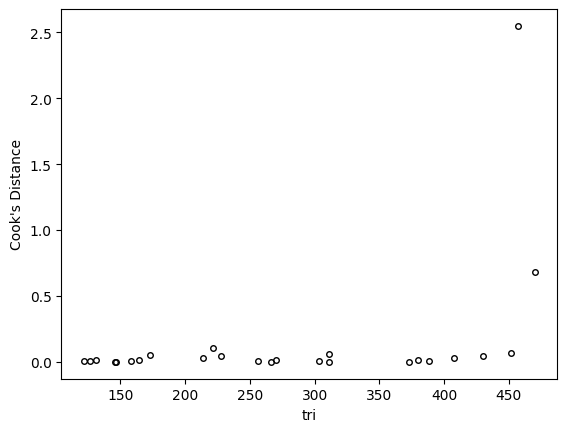

In [100]:
# smooth = lowess(cookd, df["chol"], frac=0.3) 

plt.plot(df["tri"], cookd, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("tri")
plt.ylabel("Cook's Distance")
plt.show()

Cook's distance really helps us see the influence of outliers on our predictions. The 25th datapoint (looks like an outlier) seems to have significant influence on the model's predictions.

# Fitting a polynomial model instead

In [47]:
model2 = smf.ols("y ~ age + tri + chol + I(age**2) + I(tri**2) + I(chol**2)", data=df).fit()
print(model2.summary())
print(model2.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.980e+06
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           5.84e-53
Time:                        22:12:04   Log-Likelihood:                 173.65
No. Observations:                  25   AIC:                            -333.3
Df Residuals:                      18   BIC:                            -324.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0930      0.001    -66.938   

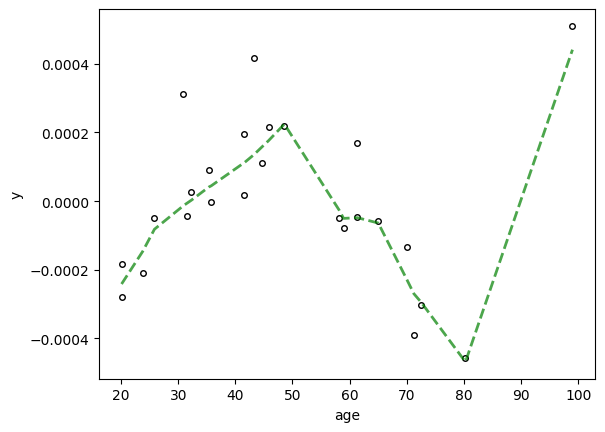

In [69]:
residuals2 = model2.resid
fitted_vals2 = model2.fittedvalues

smooth = lowess(residuals2, df["age"], frac=0.3) 

plt.plot(df["age"], residuals2, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("age")
plt.ylabel("y")
# plt.ylim(-0.2, 0.2)
plt.show()

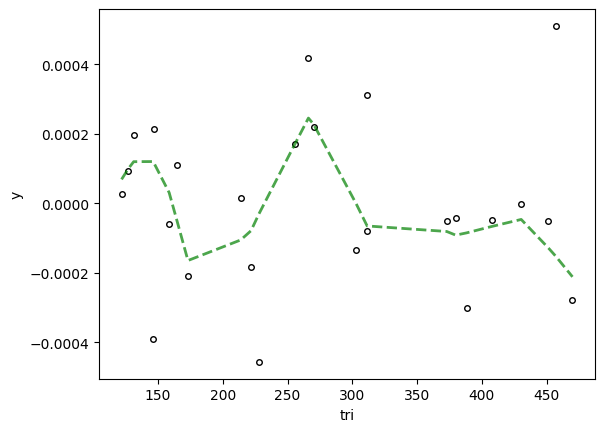

In [70]:
residuals2 = model2.resid
fitted_vals = model2.fittedvalues

smooth = lowess(residuals2, df["tri"], frac=0.3) 

plt.plot(df["tri"], residuals2, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("tri")
plt.ylabel("y")
# plt.ylim(-0.2, 0.2)
plt.show()

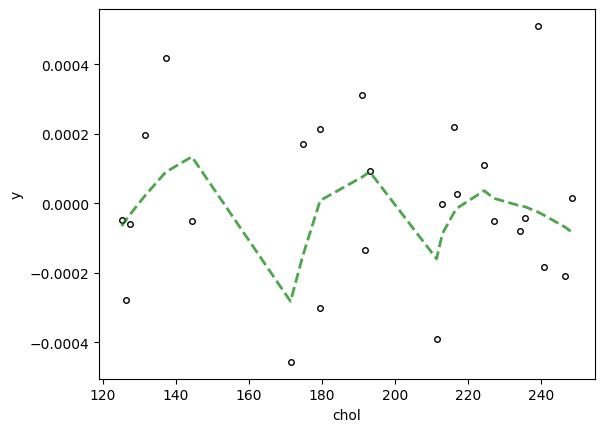

In [71]:
residuals2 = model2.resid
fitted_vals = model2.fittedvalues

smooth = lowess(residuals2, df["chol"], frac=0.3) 

plt.plot(df["chol"], residuals2, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("chol")
plt.ylabel("y")
# plt.ylim(-0.2, 0.2)
plt.show()

### Plotting the studentized residuals for the polynomial model

In [106]:
influence2 = model2.get_influence()
jackknife_residuals2 = influence2.resid_studentized_external

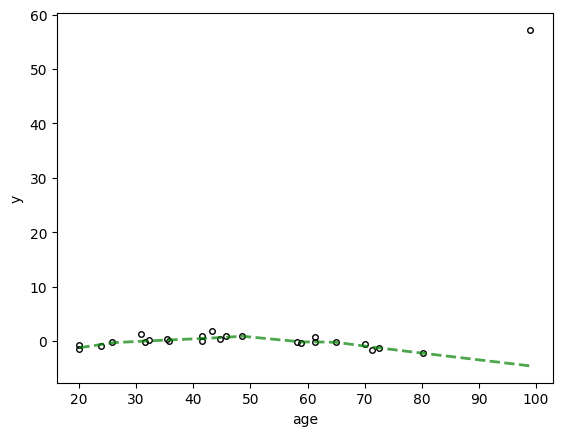

In [107]:
smooth = lowess(jackknife_residuals2, df["age"], frac=0.3) 
# smooth2 = lowess(residuals2, df["age"], frac=0.3) 

plt.plot(df["age"], jackknife_residuals2, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df["age"], residuals2, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("age")
plt.ylabel("y")
plt.show()

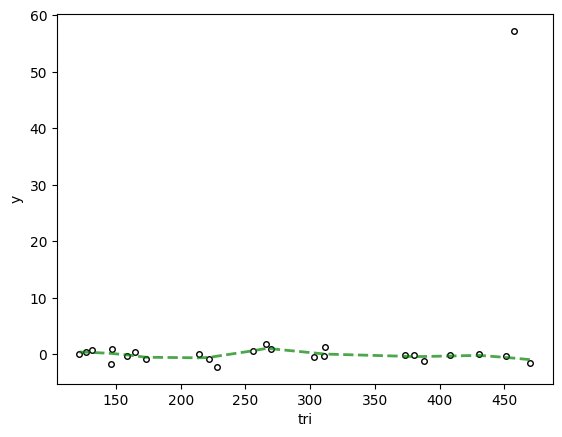

In [108]:
smooth = lowess(jackknife_residuals2, df["tri"], frac=0.3) 
# smooth2 = lowess(residuals2, df["tri"], frac=0.3) 

plt.plot(df["tri"], jackknife_residuals2, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df["tri"], residuals2, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("tri")
plt.ylabel("y")
plt.show()

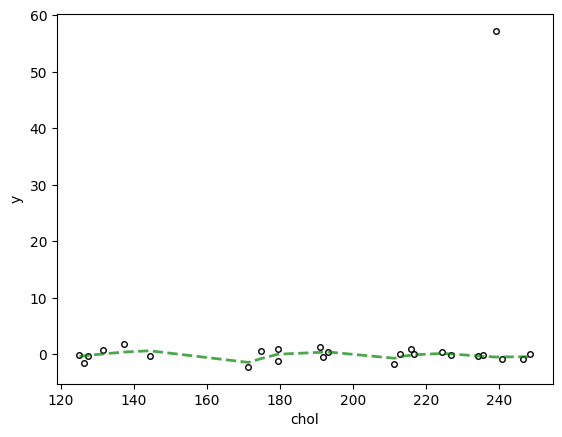

In [109]:
smooth = lowess(jackknife_residuals2, df["chol"], frac=0.3) 
# smooth2 = lowess(residuals2, df["chol"], frac=0.3) 

plt.plot(df["chol"], jackknife_residuals2, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df["chol"], residuals2, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("chol")
plt.ylabel("y")
plt.show()

### Cooks distance for the polynomial model

In [110]:
cookd2, _ = influence2.cooks_distance

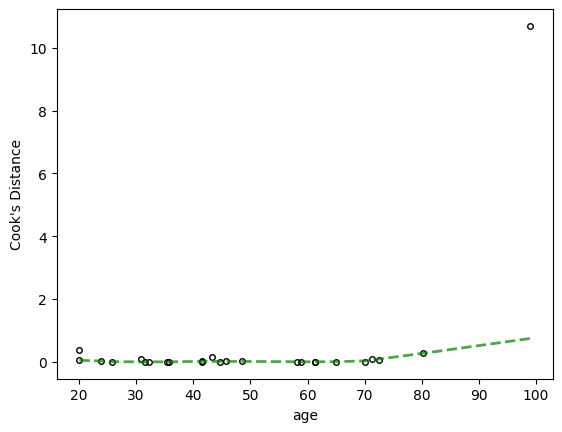

In [111]:
smooth = lowess(cookd2, df["age"], frac=0.3) 

plt.plot(df["age"], cookd2, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("age")
plt.ylabel("Cook's Distance")
plt.show()

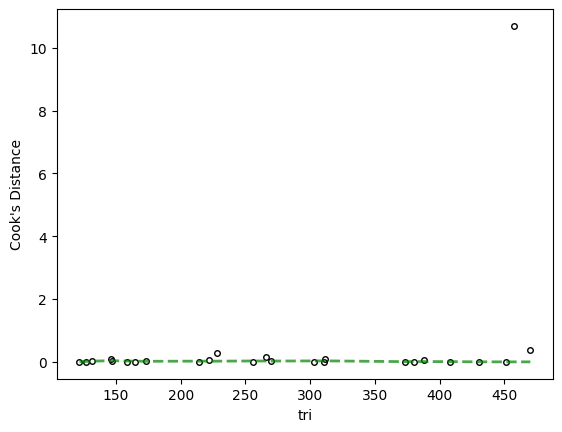

In [112]:
smooth = lowess(cookd2, df["tri"], frac=0.3) 

plt.plot(df["tri"], cookd2, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("tri")
plt.ylabel("Cook's Distance")
plt.show()

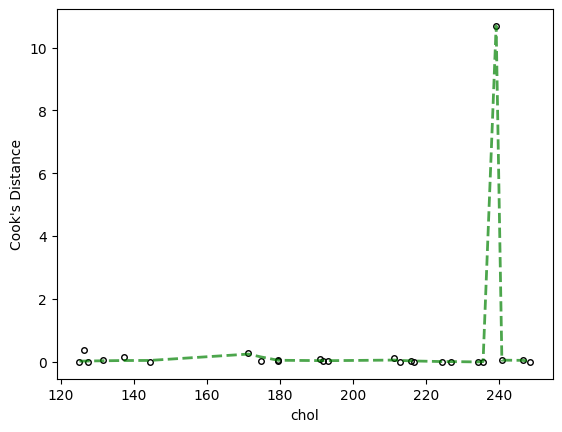

In [113]:
smooth = lowess(cookd2, df["chol"], frac=0.3) 

plt.plot(df["chol"], cookd2, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("chol")
plt.ylabel("Cook's Distance")
plt.show()

# Dropping the outlier

In [120]:
df = df.reset_index(drop=True)
# print(df)
df_new = df.drop(index=24, inplace=False)
model3 = smf.ols("y ~ age + tri + chol + I(age**2) + I(tri**2) + I(chol**2)", data=df_new).fit()
print(model3.summary())
print(model3.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.051e+08
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.66e-67
Time:                        23:06:57   Log-Likelihood:                 229.40
No. Observations:                  24   AIC:                            -444.8
Df Residuals:                      17   BIC:                            -436.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0953      0.000   -862.414   

In [121]:
influence3 = model3.get_influence()
jackknife_residuals3 = influence3.resid_studentized_external

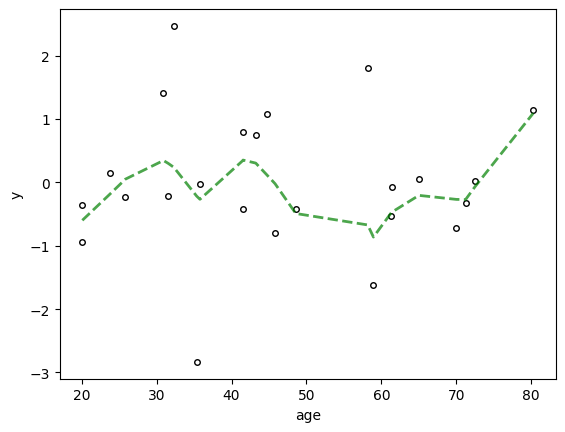

In [123]:
smooth = lowess(jackknife_residuals3, df_new["age"], frac=0.3) 
# smooth2 = lowess(residuals2, df_new["age"], frac=0.3) 

plt.plot(df_new["age"], jackknife_residuals3, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df_new["age"], residuals2, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("age")
plt.ylabel("y")
plt.show()

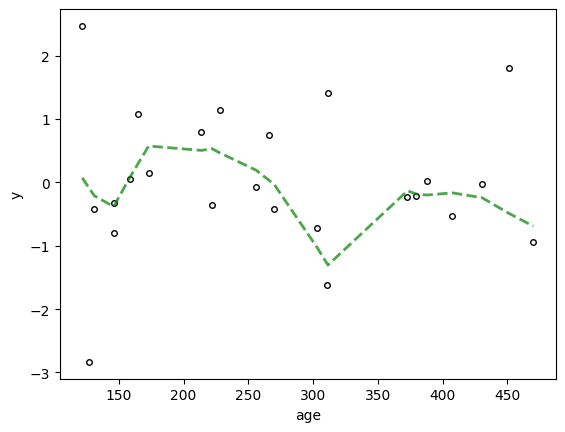

In [124]:
smooth = lowess(jackknife_residuals3, df_new["tri"], frac=0.3) 
# smooth2 = lowess(residuals2, df_new["tri"], frac=0.3) 

plt.plot(df_new["tri"], jackknife_residuals3, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df_new["tri"], residuals2, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("age")
plt.ylabel("y")
plt.show()

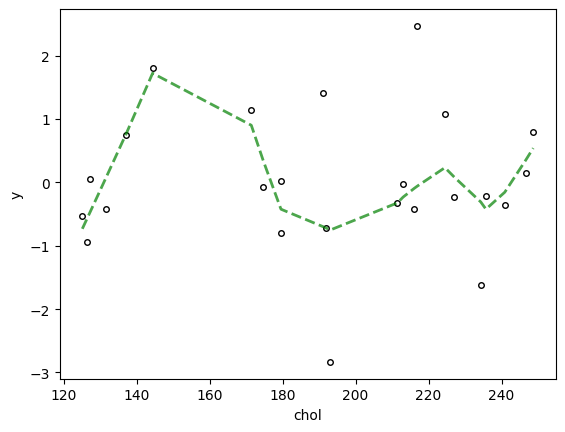

In [125]:
smooth = lowess(jackknife_residuals3, df_new["chol"], frac=0.3) 
# smooth2 = lowess(residuals2, df_new["chol"], frac=0.3) 

plt.plot(df_new["chol"], jackknife_residuals3, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(df_new["chol"], residuals2, 'o', markersize=4, fillstyle='none', color='red')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
# plt.plot(smooth2[:, 0], smooth2[:, 1], '--', alpha=0.7, color="red", linewidth=2)
plt.xlabel("chol")
plt.ylabel("y")
plt.show()